In [1]:
# Model Evaluation: Leaf Disease Diagnosis
#   This notebook performs a comprehensive evaluation of a fine-tuned ResNet50
#   model designed to identify 38 different classes of plant diseases using the
#   PlantVillage dataset.

# WorkFlow
#  - Load final trained model
#  - Load test dataset
#  - Compute predictions
#  - Print precision / recall / F1
#  - Plot confusion matrix

# Summary
# Please see the last cell in this notebook .


In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [4]:
# Load the Saved Fine-Tuned Model
import tensorflow as tf

final_model_path = "/content/gdrive/MyDrive/leaf_diagnosis_project/models/resnet_leaf_finetuned_b1.keras"
model = tf.keras.models.load_model(final_model_path)
print("Model loaded successfully!")
model.summary()

Model loaded successfully!


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_layer_3[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_1 (Stack)     │ (None, 224, 224,  │          0 │ get_item_3[0][0], │
│                     │ 3)                │            │ get_item_4[0][0], │
│                     │                   │            │ get_item_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 224, 224,  │          0 │ stack_1[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add_1[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │    262,272 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 38)        │      4,902 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 56,052,852 (213.82 MB)

 Trainable params: 16,098,982 (61.41 MB)

 Non-trainable params: 7,755,904 (29.59 MB)

 Optimizer params: 32,197,966 (122.83 MB)

In [6]:
# Copying and unzip dataset Locally on Colab
!cp /content/gdrive/MyDrive/leaf_diagnosis_project/data/plantVillage_split_processed.zip /content/
!unzip -q /content/plantVillage_split_processed.zip -d /content/data

In [7]:
# Sanity check after unzip
!ls /content/data/plantVillage_split_processed/test

 Apple___Apple_scab
 Apple___Black_rot
 Apple___Cedar_apple_rust
 Apple___healthy
 Blueberry___healthy
'Cherry_(including_sour)___healthy'
'Cherry_(including_sour)___Powdery_mildew'
'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot'
'Corn_(maize)___Common_rust_'
'Corn_(maize)___healthy'
'Corn_(maize)___Northern_Leaf_Blight'
 Grape___Black_rot
'Grape___Esca_(Black_Measles)'
 Grape___healthy
'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)'
'Orange___Haunglongbing_(Citrus_greening)'
 Peach___Bacterial_spot
 Peach___healthy
 Pepper,_bell___Bacterial_spot
 Pepper,_bell___healthy
 Potato___Early_blight
 Potato___healthy
 Potato___Late_blight
 Raspberry___healthy
 Soybean___healthy
 Squash___Powdery_mildew
 Strawberry___healthy
 Strawberry___Leaf_scorch
 Tomato___Bacterial_spot
 Tomato___Early_blight
 Tomato___healthy
 Tomato___Late_blight
 Tomato___Leaf_Mold
 Tomato___Septoria_leaf_spot
'Tomato___Spider_mites Two-spotted_spider_mite'
 Tomato___Target_Spot
 Tomato___Tomato_mosaic_virus
 Tomato_

In [8]:
# Load Test Dataset
test_dir = "/content/data/plantVillage_split_processed/test"

IMG_SIZE = (224,224)
BATCH_SIZE = 32

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False  # IMPORTANT
)

class_names = test_ds.class_names
num_classes = len(class_names)

print("Number of classes:", num_classes)

Found 8179 files belonging to 38 classes.
Number of classes: 38


In [9]:
#  Generate Predictions
import numpy as np

# True labels
y_true = np.concatenate([y.numpy() for x, y in test_ds], axis=0)

# Model predictions
y_prob = model.predict(test_ds)
y_pred = np.argmax(y_prob, axis=1)

256/256 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step


In [10]:
# Classification Report

from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred, target_names=class_names))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       1.00      0.93      0.96        95
                                 Apple___Black_rot       1.00      1.00      1.00        94
                          Apple___Cedar_apple_rust       1.00      1.00      1.00        42
                                   Apple___healthy       0.98      1.00      0.99       248
                               Blueberry___healthy       1.00      1.00      1.00       226
          Cherry_(including_sour)___Powdery_mildew       1.00      1.00      1.00       159
                 Cherry_(including_sour)___healthy       0.98      1.00      0.99       129
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.92      0.91      0.92        78
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       180
               Corn_(maize)___Northern_Leaf_Blight       0.95      0.96      0.

In [ ]:
# Overall Performance
#   Test Accuracy : 99%
#   Weighted Average F1-Score :  0.99
#   Total Test Samples: 8,179 images across 38 classes.

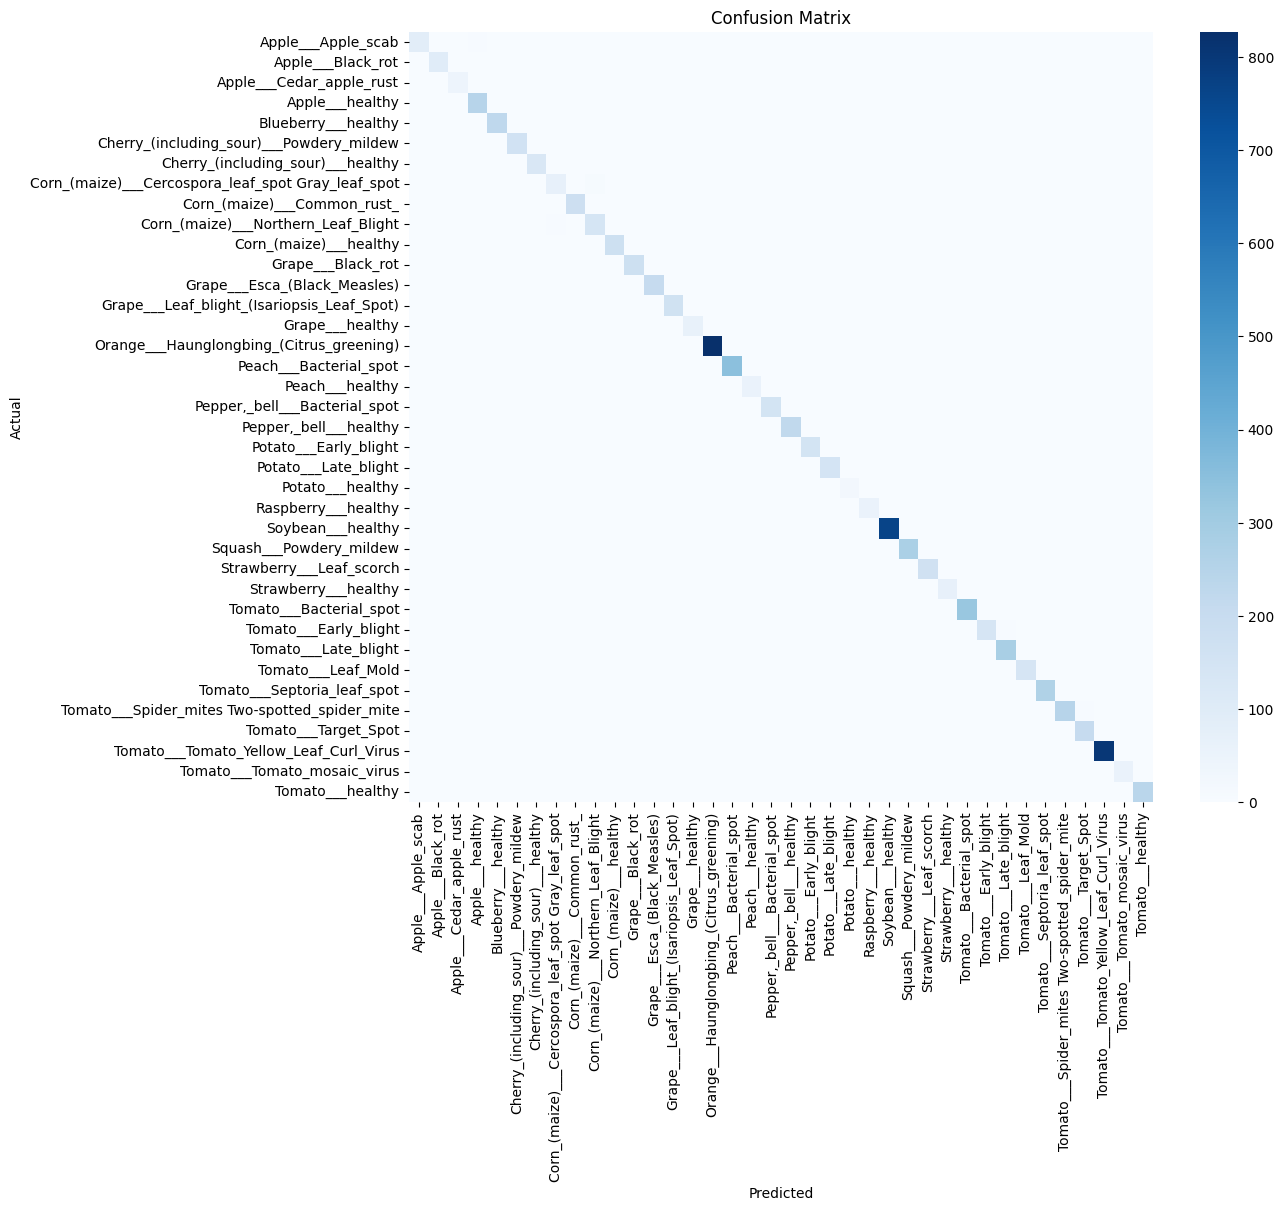

In [11]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12,10))
sns.heatmap(cm,
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues",
            fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.savefig('/content/gdrive/MyDrive/leaf_diagnosis_project/images/confusion_matrix.jpg', bbox_inches='tight')
plt.show()

In [ ]:
# Summary

# Overall Performance
#   Test Accuracy : 99%
#   Weighted Average F1-Score :  0.99
#   Total Test Samples: 8,179 images across 38 classes.

# Near-Perfect Precision & Recall:
#   Most classes (e.g., Apple Black Rot, Blueberry healthy, Orange Haunglongbing,
#   Soybean healthy, and Tomato Yellow Leaf Curl Virus) achieved perfect or
#   near-perfect scores of 1.00, indicating the model is highly reliable for the
#   majority of plant types.

# Strong Generalization:
#   Despite the complexity of distinguishing between 38 different categories,
#   the macro average precision, recall, and F1-score are all consistently at 0.99.

# Areas for Improvement
# While the results are good, a few classes show slightly lower performance compared to the rest:
# Corn (maize) Cercospora Leaf Spot:
#    This class has the lowest relative metrics with a 0.91 recall and 0.92 precision,
#    suggesting some confusion with other corn diseases like Northern Leaf Blight.
# Tomato Early Blight:
#    Shows a 0.93 recall, meaning some instances of this disease are being misclassified.
# Apple Apple Scab:
#    Also shows a 0.93 recall, indicating a small percentage of scab cases are missed.
# Potato healthy:
#    Has a lower precision of 0.92, though it maintains a perfect recall (1.00),
#    meaning the model occasionally misidentifies other potato issues as "healthy."

# Overall, the ResNet50 model is performing well for leaf disease diagnosis on this dataset.
